# Sampel 2, Motif Pinggir

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

In [3]:
edge = cv2.imread("sampel-2_motif-pinggir.png")
edge_binary = binarize(edge).astype(np.uint8)

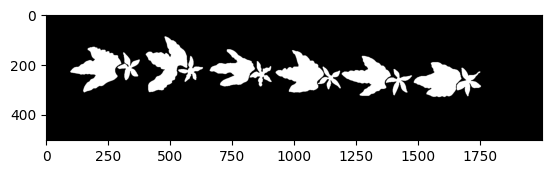

In [4]:
plt.imshow(edge_binary[2500:, 1200:], cmap='grey')

13

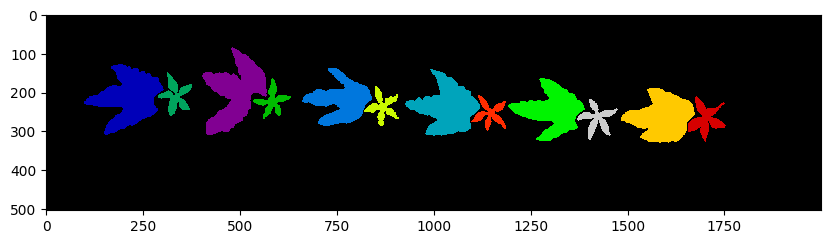

In [5]:
num_objects, objects_map, objects_stats, objects_centroids = cv2.connectedComponentsWithStats(edge_binary)

plt.figure(figsize=(10,10))
plt.imshow(objects_map[2500:, 1200:], cmap='nipy_spectral', interpolation='nearest')
num_objects

## Tiga Daun

array([0, 1, 2, 3, 4, 7, 9], dtype=int32)

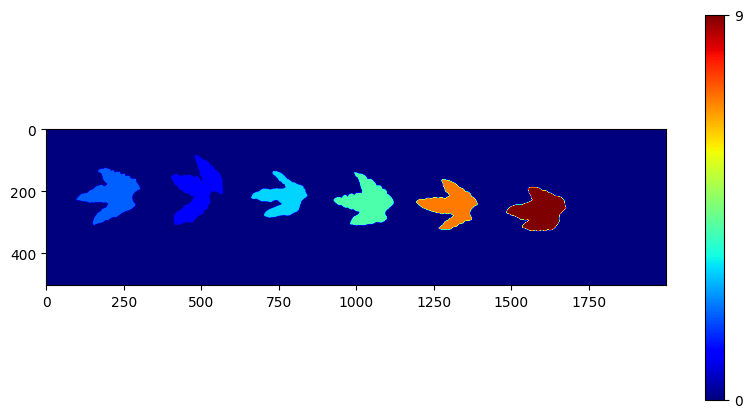

In [6]:
areas = objects_stats[1:, cv2.CC_STAT_AREA]

leaf_mask = np.zeros(num_objects, dtype='bool')
leaf_mask[1:] = areas > 10000

leaf_binary = leaf_mask[objects_map].astype(np.uint8) * 255
leaf_map = leaf_mask[objects_map] * objects_map
leaf_labels = np.unique(leaf_map)[1:]

showLabeledMap(leaf_map[2500:, 1200:])

3.092751493144889
0.07430494426619916
0.06870465946117443
0.055598552370274223
0.05744582641496487
0.01262142637233632
0.029436961063163736
0.029345343361125487
0.03625161869629556
0.06309937061222959
0.046181837470073095
0.05187270816518241
0.02906722090923486
0.04633627696644682
0.06275698097595628


(5,)

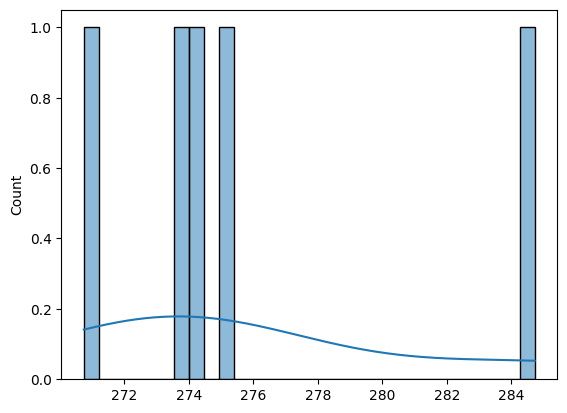

In [7]:
leaf_center_distance_list = []
leaf_orientation_distance_list = []

for i in range(0, len(leaf_labels)-1):
    for j in range(i+1, len(leaf_labels)):
        center_distance = getNeighborCenterDistance(objects_centroids, [leaf_labels[i], leaf_labels[j]])
        orientation = getNeighborOrientationDistance(objects_centroids, [leaf_labels[i], leaf_labels[j]])
        print(orientation)
        leaf_center_distance_list.append(center_distance)
        leaf_orientation_distance_list.append(np.degrees(orientation))

leaf_orientation_distance_list = np.array(leaf_orientation_distance_list)
leaf_center_distance_list = np.array(leaf_center_distance_list)
leaf_orientation_distance_list = leaf_orientation_distance_list[leaf_center_distance_list < 400]
leaf_center_distance_list = leaf_center_distance_list[leaf_center_distance_list < 400]

sns.histplot(leaf_center_distance_list, kde=True, bins=30)

leaf_center_distance_list.shape

In [8]:
summarizeData(leaf_center_distance_list, "Leaf Horizontal Distance")

DATA SUMMARY of [Leaf Horizontal Distance]:
Num     : 5
Mean    : 275.7282
SD      : 4.7351
SD rel  : 1.72%
Median  : 274.1424
MAD     : 0.9842
MAD rel : 0.36%
Min     : 270.7439
Max     : 284.7302



{'num': 5,
 'mean': 275.7281712371449,
 'sd': 4.735097065383221,
 'median': 274.1424359532192,
 'mad': 0.9841741015089269,
 'min': 270.7439345030315,
 'max': 284.7301740213765}

array([177.20160764,   4.2573597 ,   3.61532763,   1.66542908,
         3.59571014])

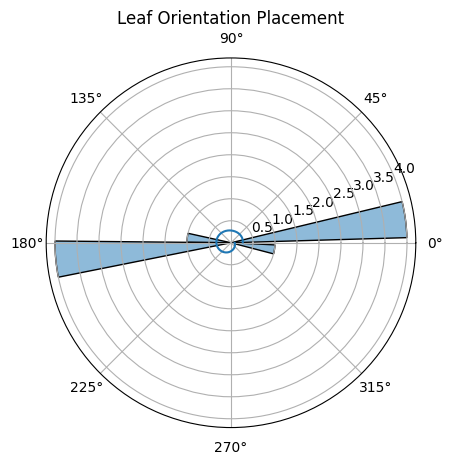

In [9]:
leaf_orientation_distance_repeated = np.concatenate((leaf_orientation_distance_list, leaf_orientation_distance_list + 180))

ax = plt.axes(projection='polar')
sns.histplot(leaf_orientation_distance_repeated / 180 * np.pi, ax=ax, kde=True, bins=30)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Leaf Orientation Placement")

leaf_orientation_distance_list

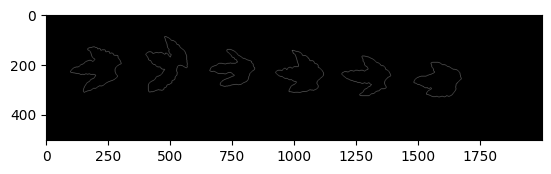

In [10]:
leaf_contour = extractContours(leaf_binary)
leaf_contour_map = createContourMap(leaf_binary.shape, leaf_contour)

plt.imshow(leaf_contour_map[2500:, 1200:], cmap='grey')

In [11]:
leaf_contour_interpolated = interpolateContours(leaf_contour, 100)
leaf_mean_shape, leaf_contours_rotated = processGPA(leaf_contour_interpolated)

4.958434203220402e-06


In [12]:
leaf_procrustes_distances = procrustesDistances(leaf_mean_shape, leaf_contours_rotated)
summarizeData(leaf_procrustes_distances, "Procrustes Analysis")

DATA SUMMARY of [Procrustes Analysis]:
Num     : 6
Mean    : 0.1728
SD      : 0.0389
SD rel  : 22.50%
Median  : 0.1705
MAD     : 0.0203
MAD rel : 11.90%
Min     : 0.1230
Max     : 0.2470



{'num': 6,
 'mean': 0.17281711078550646,
 'sd': 0.038892335239542615,
 'median': 0.1705192272482564,
 'mad': 0.020294667037674338,
 'min': 0.12303084228200278,
 'max': 0.24699904649181664}

In [13]:
leaf_contour_areas = contourAreas(leaf_contour)
summarizeData(np.sqrt(leaf_contour_areas), "Big Variant Rooted Areas")

DATA SUMMARY of [Big Variant Rooted Areas]:
Num     : 6
Mean    : 125.4253
SD      : 7.5830
SD rel  : 6.05%
Median  : 127.0034
MAD     : 6.3328
MAD rel : 4.99%
Min     : 111.9620
Max     : 134.0131



{'num': 6,
 'mean': 125.42526878263082,
 'sd': 7.583004075220758,
 'median': 127.00339256507274,
 'mad': 6.332806045526098,
 'min': 111.96204714098434,
 'max': 134.0130590651523}

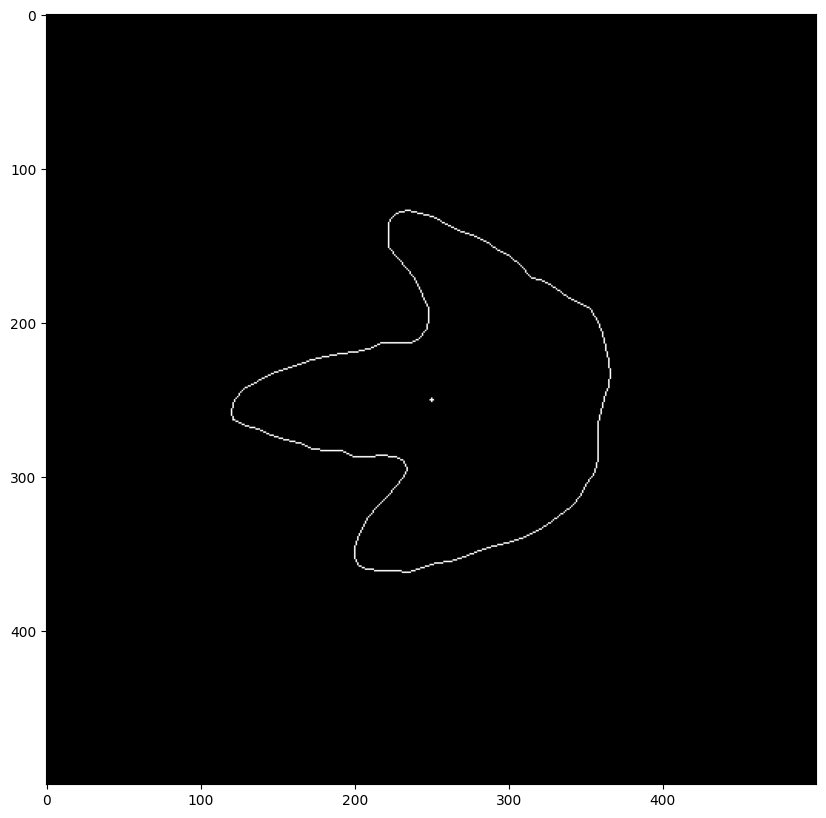

In [14]:
leaf_size_factor = 1000

leaf_mean_shape_binary = drawStandardizedContour((500, 500), leaf_mean_shape, leaf_size_factor)

plt.figure(figsize=(10, 10))
plt.imshow(leaf_mean_shape_binary, cmap='gray')

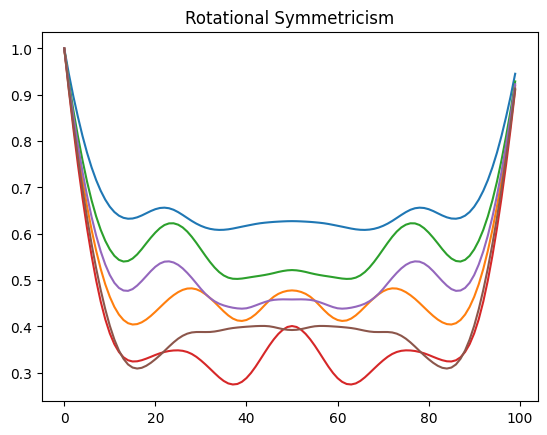

In [15]:
plt.title("Rotational Symmetricism")
for shape in leaf_contours_rotated:
    sns.lineplot(testRotationalSymmetry(shape))

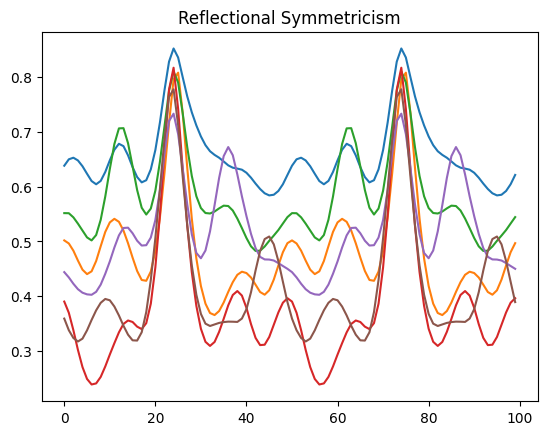

In [16]:
plt.title("Reflectional Symmetricism")
for shape in leaf_contours_rotated:
    sns.lineplot(testReflectionalSymmetry(shape))

## Bintang

array([ 0,  5,  6,  8, 10, 11, 12], dtype=int32)

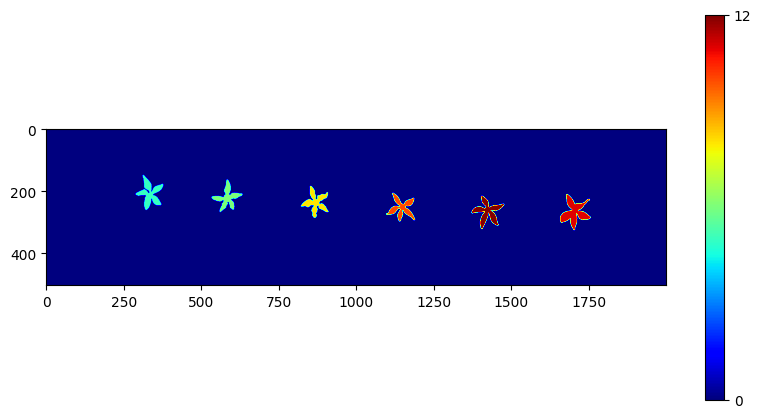

In [17]:
star_mask = np.zeros(num_objects, dtype='bool')
star_mask[1:] = areas <= 10000

star_binary = star_mask[objects_map].astype(np.uint8) * 255
star_map = star_mask[objects_map] * objects_map
star_labels = np.unique(star_map)[1:]

showLabeledMap(star_map[2500:, 1200:])

0.05064512752781747
0.052752923591183
0.057169909438109734
0.0445302052476948
0.05520404523344613
0.05459507475126424
0.060058219987237926
0.04316819735577182
0.056556944664316156
0.06566521426114846
0.039260144935092
0.05756559393498817
0.026067898576809245
0.049436101822455836
0.0029152804130917766


(5,)

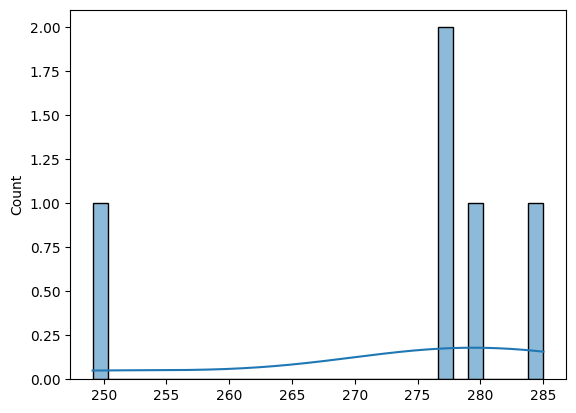

In [18]:
star_center_distance_list = []
star_orientation_distance_list = []

for i in range(0, len(star_labels)-1):
    for j in range(i+1, len(star_labels)):
        center_distance = getNeighborCenterDistance(objects_centroids, [star_labels[i], star_labels[j]])
        orientation = getNeighborOrientationDistance(objects_centroids, [star_labels[i], star_labels[j]])
        print(orientation)
        star_center_distance_list.append(center_distance)
        star_orientation_distance_list.append(np.degrees(orientation))

star_orientation_distance_list = np.array(star_orientation_distance_list)
star_center_distance_list = np.array(star_center_distance_list)
star_orientation_distance_list = star_orientation_distance_list[star_center_distance_list < 400]
star_center_distance_list = star_center_distance_list[star_center_distance_list < 400]

sns.histplot(star_center_distance_list, kde=True, bins=30)

star_center_distance_list.shape

In [19]:
summarizeData(star_center_distance_list, "Leaf Horizontal Distance")

DATA SUMMARY of [Leaf Horizontal Distance]:
Num     : 5
Mean    : 273.5693
SD      : 12.5639
SD rel  : 4.59%
Median  : 277.7218
MAD     : 1.5556
MAD rel : 0.56%
Min     : 249.1116
Max     : 285.0343



{'num': 5,
 'mean': 273.56926023774577,
 'sd': 12.56392358444372,
 'median': 277.721764153357,
 'mad': 1.5555659090281893,
 'min': 249.11158053437097,
 'max': 285.0343274437149}

array([2.90175206, 3.12806737, 3.76233964, 2.83247999, 0.16703326])

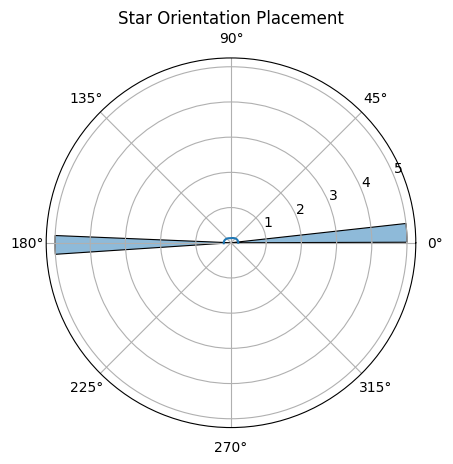

In [20]:
star_orientation_distance_repeated = np.concatenate((star_orientation_distance_list, star_orientation_distance_list + 180))

ax = plt.axes(projection='polar')
sns.histplot(star_orientation_distance_repeated / 180 * np.pi, ax=ax, kde=True, bins=30)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Star Orientation Placement")

star_orientation_distance_list

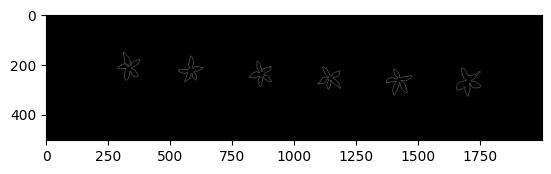

In [21]:
star_contour = extractContours(star_binary)
star_contour_map = createContourMap(star_binary.shape, star_contour)

plt.imshow(star_contour_map[2500:, 1200:], cmap='grey')

In [22]:
star_contour_interpolated = interpolateContours(star_contour, 100)
star_mean_shape, star_contours_rotated = processGPA(star_contour_interpolated)

1.338921161807981e-06


In [23]:
star_procrustes_distances = procrustesDistances(star_mean_shape, star_contours_rotated)
summarizeData(star_procrustes_distances, "Procrustes Analysis")

DATA SUMMARY of [Procrustes Analysis]:
Num     : 6
Mean    : 0.1725
SD      : 0.0235
SD rel  : 13.61%
Median  : 0.1751
MAD     : 0.0218
MAD rel : 12.47%
Min     : 0.1375
Max     : 0.2057



{'num': 6,
 'mean': 0.172473912060378,
 'sd': 0.023482272176404563,
 'median': 0.17509290289107418,
 'mad': 0.021832759069643173,
 'min': 0.137537135784807,
 'max': 0.20573070798683726}

In [24]:
star_contour_areas = contourAreas(star_contour)
summarizeData(np.sqrt(star_contour_areas), "Big Variant Rooted Areas")

DATA SUMMARY of [Big Variant Rooted Areas]:
Num     : 6
Mean    : 57.8482
SD      : 4.1229
SD rel  : 7.13%
Median  : 56.7909
MAD     : 2.6987
MAD rel : 4.75%
Min     : 53.8377
Max     : 65.6354



{'num': 6,
 'mean': 57.84823539777946,
 'sd': 4.122902864458694,
 'median': 56.79091864999661,
 'mad': 2.698744686632182,
 'min': 53.83771911959124,
 'max': 65.63535632568775}

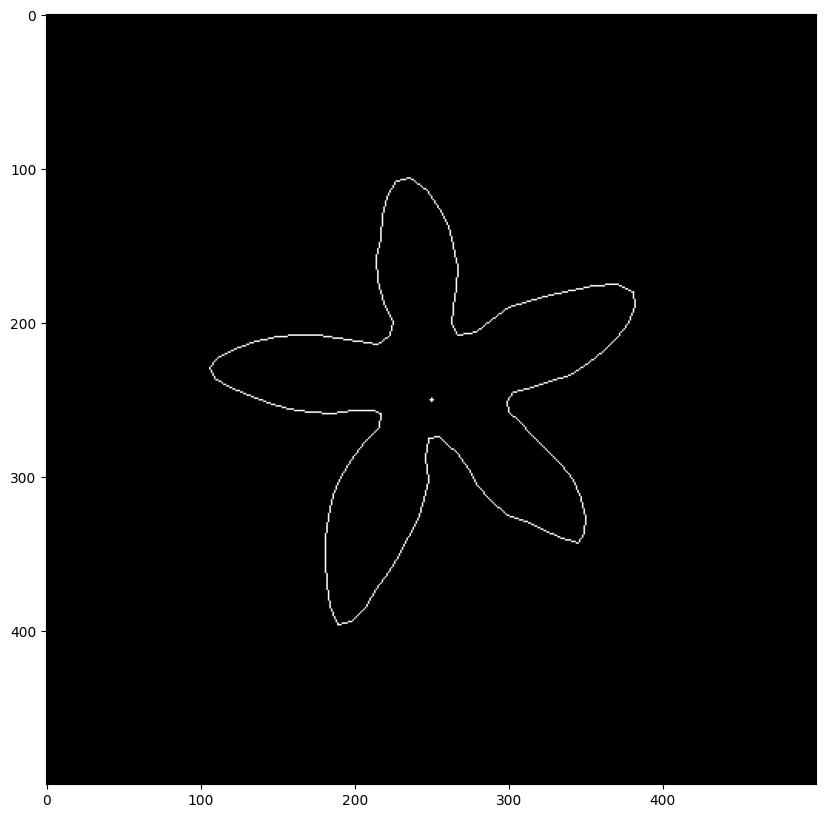

In [25]:
star_size_factor = 1000

star_mean_shape_binary = drawStandardizedContour((500, 500), star_mean_shape, star_size_factor)

plt.figure(figsize=(10, 10))
plt.imshow(star_mean_shape_binary, cmap='gray')

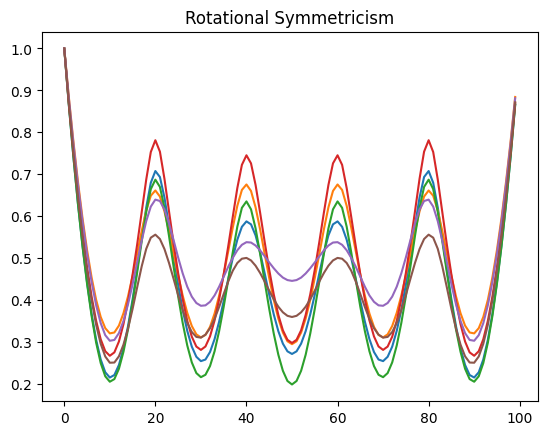

In [26]:
plt.title("Rotational Symmetricism")
for shape in star_contours_rotated:
    sns.lineplot(testRotationalSymmetry(shape))

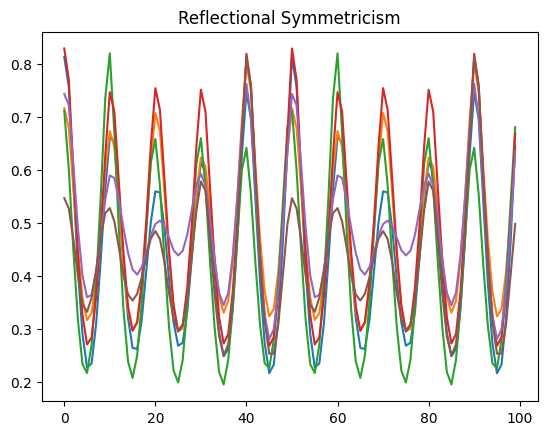

In [27]:
plt.title("Reflectional Symmetricism")
for shape in star_contours_rotated:
    sns.lineplot(testReflectionalSymmetry(shape))